# Testing resolution/frame-overlap when one of the double disc choppers are slowed down

# McStas Results from Mo

##  RRM=22

Ei | Mode | Resolution | Percetage
|---|---|---|---|
80 meV (1.011 Å)| OG | 3.67 meV | 4.6%
80 meV (1.011 Å)| M2 | 4.31 meV | 5.4%
50 meV (1.279 Å)| OG | 1.78 meV | 3.0%
50 meV (1.279 Å)| M2 | 2.07 meV | 4.1%
20 meV (2.022 Å)| OG | 0.46 meV | 2.3%
20 meV (2.022 Å)| M2 | 0.54 meV | 2.7%




# Original RRM=20, getting 15

In [1]:
%matplotlib widget

import scipp as sc
from drtrex.instrument import Instrument
from drtrex.sample import Sample
from drtrex.components.source import Source


central_wavelength = 1.279 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 20
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(
    central_wavelength, rrm, mode, T_OFFSET, chopper_slowdown=(1, 1, 1, 1)
)
trex.source = Source(
    facility="ess-trex", neutrons=5_000_000, optimize_for=trex.choppers
)
res_elastic_rrm20 = trex.run()
sample = Sample(en={"uniform": (40, 60)})
res_inelastic_rrm20 = trex.run(sample)

# Inelastic

(160.0, 168.0)

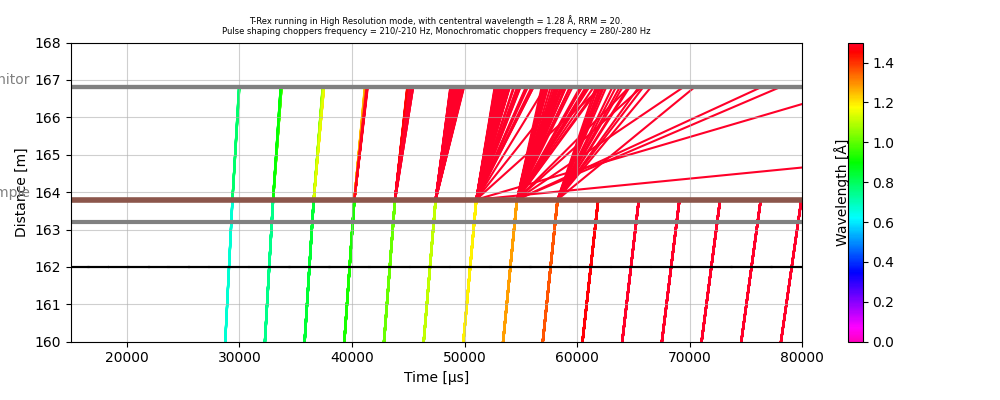

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm20.plot(ax=ax, vmin=0, vmax=1.5)
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()
ax.set_xlim([15_000, 80_000])
ax.set_ylim([160, 168])


In [3]:
import plopp as pp

data = res_inelastic_rrm20.detectors["Detector"].data["pulse", 0]
data = data[~data.masks["blocked_by_others"]]
pp.plot(data.hist(toa=sc.arange("toa", 15_000, 80_000, 1, unit="us")), grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

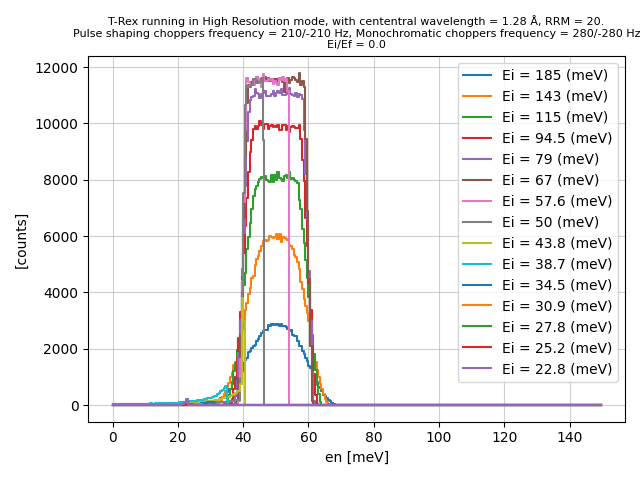

In [4]:
import plopp as pp

ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm20)
params = trex.unwrap_frame(res_elastic_rrm20, ei_ef_ratio=ei_ef_ratio)
# trex.wrap_frame(res_inelastic_rrm22)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm20, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", 0, 150, 0.5, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

# Elastic

In [5]:
trex.wrap_frame(res_elastic_rrm20)
params = trex.unwrap_frame(res_elastic_rrm20, ei_ef_ratio=0.0)
reduced_elastic = trex.toa_to_energy(res_elastic_rrm20, *params)

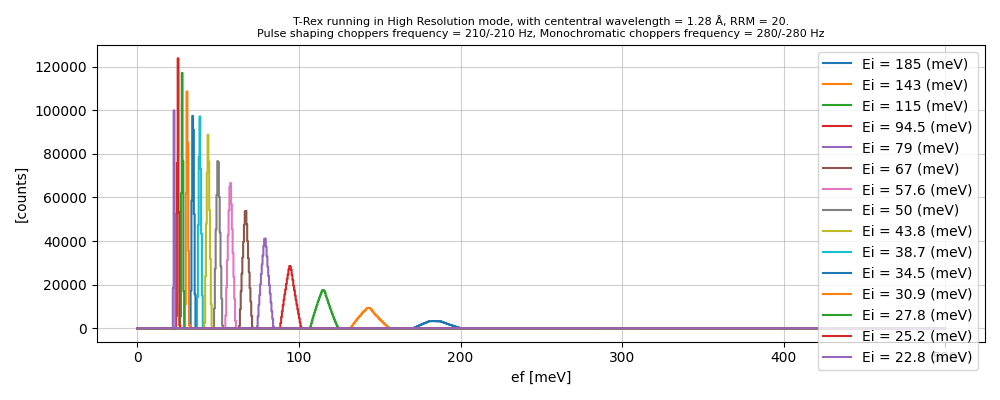

In [6]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 500, 0.5, unit="meV")
    )
    for reduced in reduced_elastic
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
# ax.set_ylim([-50, 12_000])
fig.tight_layout()

In [7]:
cen = [
    (da.data * sc.midpoints(da.coords["ef"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (da.data * (sc.midpoints(da.coords["ef"] - cen[i].data)) ** 2).sum() / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
print(f"Ei  = {[round(float(v.data.value), 4) for v in cen]} meV")
print(f"delta en FWHM  = {[round(float(v.data.value), 4) for v in fwhm]} meV")
ratio = [round(float(f.data / c.data), 3) for f, c in zip(fwhm, cen)]
print(f"delta en over ei = {ratio}")

Ei  = [184.7114, 143.3103, 115.1817, 94.6032, 79.0718, 67.0779, 57.6179, 50.0286, 43.843, 38.736, 34.4753, 30.8766, 27.8183, 25.1899, 22.8492] meV
delta en FWHM  = [14.4923, 11.59, 8.364, 6.3213, 4.8749, 3.843, 3.0965, 2.5297, 2.0703, 1.7111, 1.4451, 1.2221, 1.0542, 0.9026, 0.7217] meV
delta en over ei = [0.078, 0.081, 0.073, 0.067, 0.062, 0.057, 0.054, 0.051, 0.047, 0.044, 0.042, 0.04, 0.038, 0.036, 0.032]


# Having M2 slowed down by a factor of 2

In [8]:
trex = Instrument(
    central_wavelength, rrm, mode, T_OFFSET, chopper_slowdown=(1, 1, 1, 2)
)
trex.source = Source(
    facility="ess-trex", neutrons=5_000_000, optimize_for=trex.choppers
)
res_elastic_rrm20 = trex.run()
sample = Sample(en={"uniform": (40, 60)})
res_inelastic_rrm20 = trex.run(sample)

(160.0, 168.0)

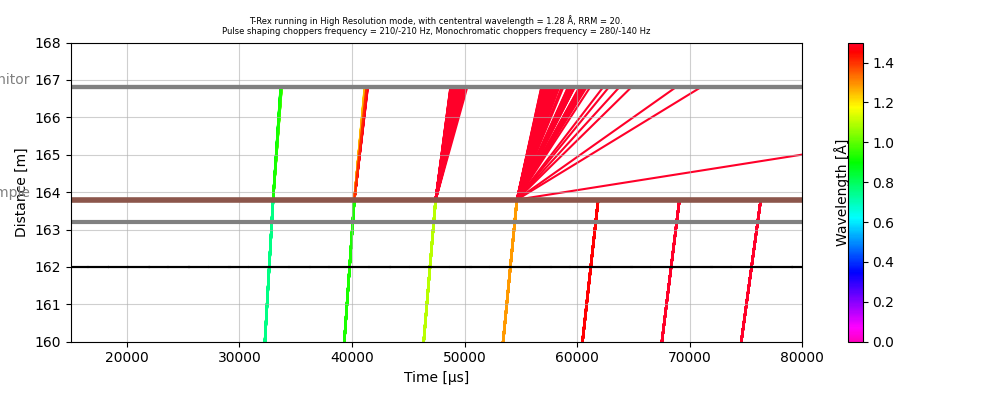

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm20.plot(ax=ax, vmin=0, vmax=1.5)
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()
ax.set_xlim([15_000, 80_000])
ax.set_ylim([160, 168])


In [10]:
data = res_inelastic_rrm20.detectors["Detector"].data["pulse", 0]
data = data[~data.masks["blocked_by_others"]]
pp.plot(data.hist(toa=sc.arange("toa", 15_000, 80_000, 1, unit="us")), grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

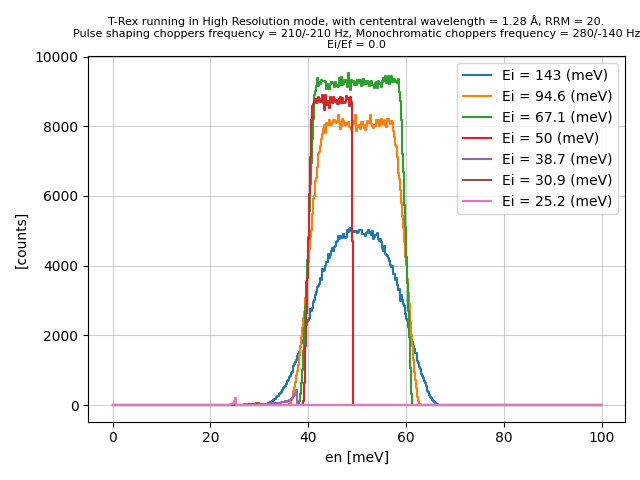

In [11]:
ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm20)
params = trex.unwrap_frame(res_elastic_rrm20, ei_ef_ratio=ei_ef_ratio)
# trex.wrap_frame(res_inelastic_rrm22)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm20, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", 0, 100, 0.2, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [12]:
trex.wrap_frame(res_elastic_rrm20)
params = trex.unwrap_frame(res_elastic_rrm20, ei_ef_ratio=0.0)
reduced_elastic = trex.toa_to_energy(res_elastic_rrm20, *params)

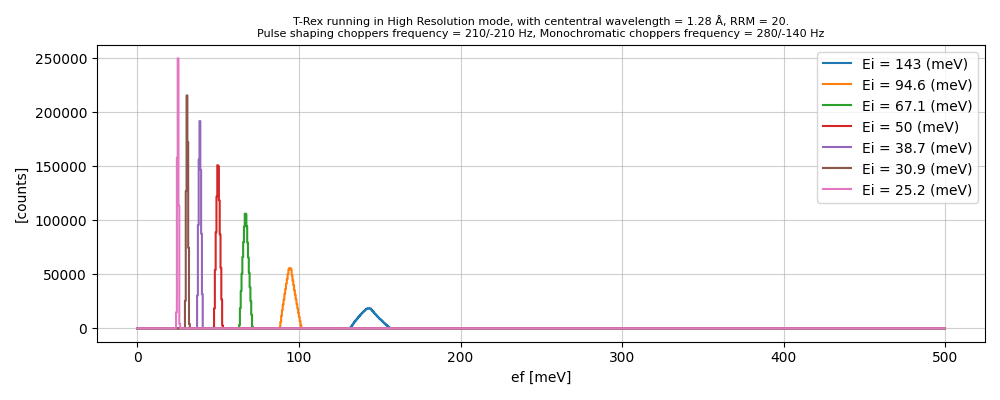

In [13]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 500, 0.5, unit="meV")
    )
    for reduced in reduced_elastic
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
# ax.set_ylim([-50, 12_000])
fig.tight_layout()

In [14]:
cen = [
    (da.data * sc.midpoints(da.coords["ef"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (da.data * (sc.midpoints(da.coords["ef"] - cen[i].data)) ** 2).sum() / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
print(f"Ei  = {[round(float(v.data.value), 4) for v in cen]} meV")
print(f"delta en FWHM  = {[round(float(v.data.value), 4) for v in fwhm]} meV")
ratio = [round(float(f.data / c.data), 3) for f, c in zip(fwhm, cen)]
print(f"delta en over ei = {ratio}")

Ei  = [143.3412, 94.6108, 67.081, 50.0272, 38.7363, 30.8758, 25.1893] meV
delta en FWHM  = [11.9905, 6.4637, 3.8963, 2.5326, 1.7294, 1.2493, 0.9319] meV
delta en over ei = [0.084, 0.068, 0.058, 0.051, 0.045, 0.04, 0.037]


# Having M2 slowed down by a factor of 4

In [15]:
trex = Instrument(
    central_wavelength, rrm, mode, T_OFFSET, chopper_slowdown=(1, 1, 1, 4)
)
trex.source = Source(
    facility="ess-trex", neutrons=5_000_000, optimize_for=trex.choppers
)
res_elastic_rrm20 = trex.run()
sample = Sample(en={"uniform": (40, 60)})
res_inelastic_rrm20 = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_81108/2557016823.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


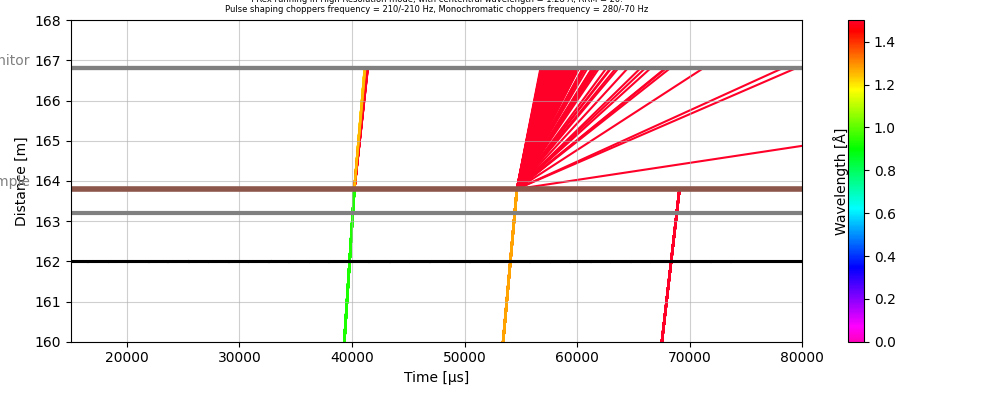

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm20.plot(ax=ax, vmin=0, vmax=1.5)
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
ax.set_xlim([15_000, 80_000])
ax.set_ylim([160, 168])

fig.tight_layout()

In [17]:
data = res_inelastic_rrm20.detectors["Detector"].data["pulse", 0]
data = data[~data.masks["blocked_by_others"]]
pp.plot(data.hist(toa=sc.arange("toa", 15_000, 80_000, 1, unit="us")), grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

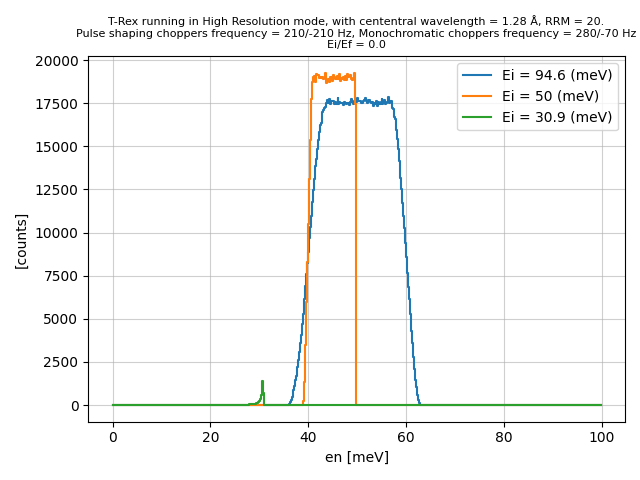

In [18]:
ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm20)
params = trex.unwrap_frame(res_elastic_rrm20, ei_ef_ratio=ei_ef_ratio)
# trex.wrap_frame(res_inelastic_rrm22)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm20, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords["kf_over_ki"]
    reduced.data *= sc.sqrt(reduced.coords["ei"] / reduced.coords["ef"])

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", 0, 100, 0.2, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [19]:
trex.wrap_frame(res_elastic_rrm20)
params = trex.unwrap_frame(res_elastic_rrm20, ei_ef_ratio=0.0)
reduced_elastic = trex.toa_to_energy(res_elastic_rrm20, *params)

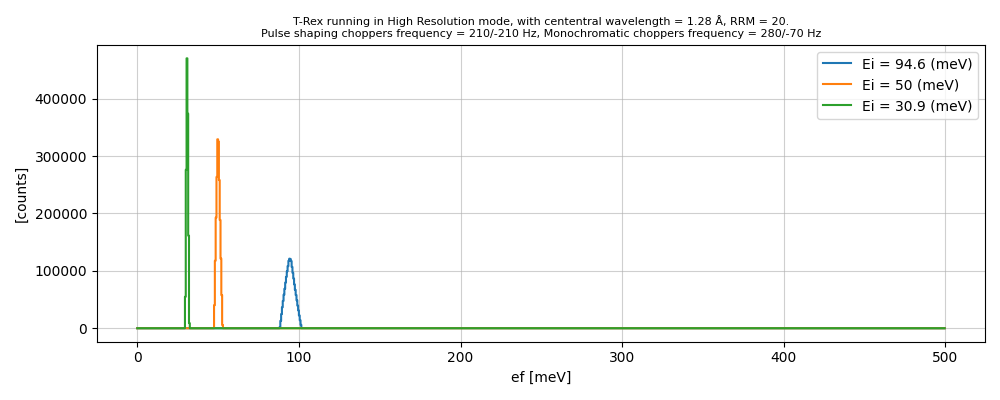

In [20]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 500, 0.5, unit="meV")
    )
    for reduced in reduced_elastic
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
# ax.set_ylim([-50, 12_000])
fig.tight_layout()

In [21]:
cen = [
    (da.data * sc.midpoints(da.coords["ef"])).sum() / da.sum()
    for da in hist_dict.values()
]
fwhm = [
    2.355
    * sc.sqrt(
        (da.data * (sc.midpoints(da.coords["ef"] - cen[i].data)) ** 2).sum() / da.sum()
    )
    for i, da in enumerate(hist_dict.values())
]
print(f"Ei  = {[round(float(v.data.value), 4) for v in cen]} meV")
print(f"delta en FWHM  = {[round(float(v.data.value), 4) for v in fwhm]} meV")
ratio = [round(float(f.data / c.data), 3) for f, c in zip(fwhm, cen)]
print(f"delta en over ei = {ratio}")

Ei  = [94.61, 50.0273, 30.8754] meV
delta en FWHM  = [6.468, 2.5337, 1.2473] meV
delta en over ei = [0.068, 0.051, 0.04]
